# Proiect 1 ML - Clasificare: Wine Quality Red

**Autor:** jackjack242
**Curs:** Sisteme Inteligente

## 1. Definirea problemei

Avem un set cu 1599 de vinuri rosii, descrise prin 11 proprietati fizico-chimice
(aciditate, zahar rezidual, alcool, etc.) si un scor de calitate intre 0 si 10
dat de un expert. Vreau sa antrenez un model care sa imi spuna **daca un vin e
"bun" sau nu**, in functie doar de proprietatile chimice. Asta e o problema de
**clasificare binara**.

**Target:** `quality >= 6` -> 1 (vin bun), altfel 0.

**Variabile de intrare:** `fixed acidity`, `volatile acidity`, `citric acid`,
`residual sugar`, `chlorides`, `free sulfur dioxide`, `total sulfur dioxide`,
`density`, `pH`, `sulphates`, `alcohol`.

### De ce e util?
Producatorii pot estima rapid calitatea unui vin fara sa astepte degustarea unui
expert - daca chimia spune ca-i probabil "bun", merita scos pe piata. E un caz
clasic de inlocuire a evaluarii umane subiective cu un proxy obiectiv.

### De ce am ales asta?
- Set bine cunoscut, curat (nu am chinuri cu missing-uri)
- Toate caracteristicile numerice -> EDA fara batai de cap cu encoding
- Marime potrivita (1599 obs) - se antreneaza repede toate modelele
- Distributia target-ului e relativ echilibrata (53/47), deci accuracy nu pacaleste


In [1]:
import warnings
warnings.filterwarnings('ignore')

import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, GridSearchCV, learning_curve, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,
                             roc_curve)

from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from interpret.glassbox import ExplainableBoostingClassifier

import shap

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
DATA_PATH = ROOT / 'data' / 'wine_red.csv'
MODELS_DIR = ROOT / 'models' / 'clf'
PLOTS_DIR = ROOT / 'plots' / 'clf'
MODELS_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

RNG = 42
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 90


## 2. Analiza exploratorie a datelor (EDA)

In [2]:
df = pd.read_csv(DATA_PATH)
print('Shape:', df.shape)
df.head()

Shape: (1599, 12)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [3]:
# tipuri si statistici de baza
print(df.dtypes)
print()
print('Missing values:', df.isna().sum().sum())
df.describe().T

fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
dtype: object

Missing values: 0


,count,mean,std,min,25%,50%,75%,max
fixed acidity,1599.0,8.319637,1.741096,4.60000,7.1000,7.90000,9.200000,15.90000
volatile acidity,1599.0,0.527821,0.179060,0.12000,0.3900,0.52000,0.640000,1.58000
citric acid,1599.0,0.270976,0.194801,0.00000,0.0900,0.26000,0.420000,1.00000
residual sugar,1599.0,2.538806,1.409928,0.90000,1.9000,2.20000,2.600000,15.50000
chlorides,1599.0,0.087467,0.047065,0.01200,0.0700,0.07900,0.090000,0.61100
free sulfur dioxide,1599.0,15.874922,10.460157,1.00000,7.0000,14.00000,21.000000,72.00000
total sulfur dioxide,1599.0,46.467792,32.895324,6.00000,22.0000,38.00000,62.000000,289.00000
density,1599.0,0.996747,0.001887,0.99007,0.9956,0.99675,0.997835,1.00369
pH,1599.0,3.311113,0.154386,2.74000,3.2100,3.31000,3.400000,4.01000
sulphates,1599.0,0.658149,0.169507,0.33000,0.5500,0.62000,0.730000,2.00000


**Observatii rapide:**
- Toate cele 12 coloane sunt numerice (`float64`/`int64`).
- Nu am missing values - bonus.
- `quality` e variabila de iesire originala, ia valori intre 3 si 8.
- Range-urile difera mult intre features (`total sulfur dioxide` ajunge la sute,
  `chlorides` e in zecimi). O sa standardizez pentru modelele bazate pe distante
  (KNN, SVM) si pentru cele cu regularizare (LogReg).


good
1    855
0    744
Name: count, dtype: int64
Procent vinuri bune: 53.5%


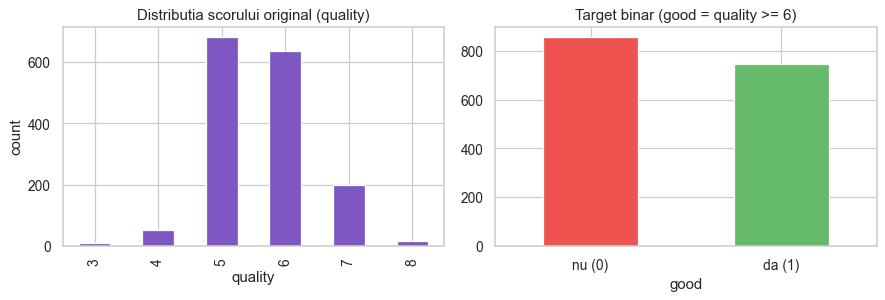

In [4]:
# construiesc target binar: vin bun = quality >= 6
df['good'] = (df['quality'] >= 6).astype(int)
print(df['good'].value_counts())
print(f"Procent vinuri bune: {df['good'].mean()*100:.1f}%")

fig, ax = plt.subplots(1, 2, figsize=(10, 3.5))
df['quality'].value_counts().sort_index().plot(kind='bar', ax=ax[0], color='#7e57c2')
ax[0].set_title('Distributia scorului original (quality)')
ax[0].set_xlabel('quality'); ax[0].set_ylabel('count')

df['good'].value_counts().plot(kind='bar', ax=ax[1], color=['#ef5350', '#66bb6a'])
ax[1].set_title('Target binar (good = quality >= 6)')
ax[1].set_xticklabels(['nu (0)', 'da (1)'], rotation=0)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'eda_target.png', dpi=110, bbox_inches='tight')
plt.show()

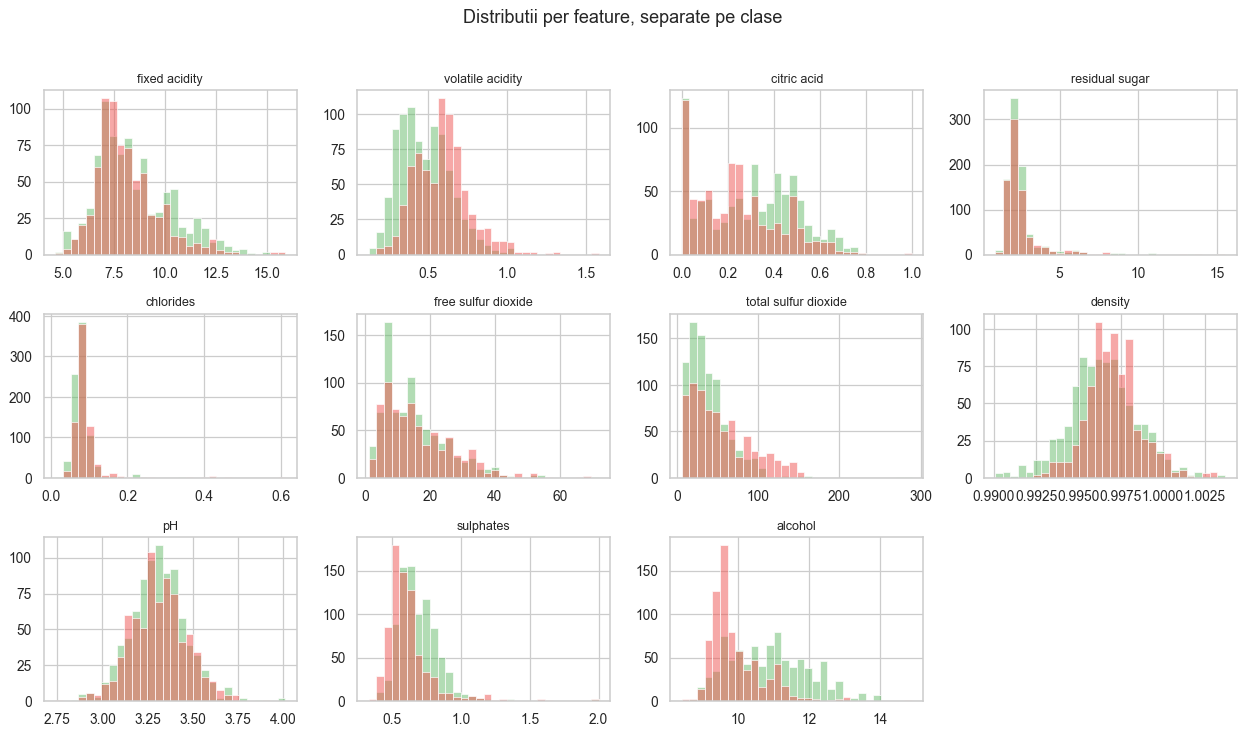

In [5]:
# distributia fiecarei feature
features = [c for c in df.columns if c not in ('quality', 'good')]
fig, axes = plt.subplots(3, 4, figsize=(14, 8))
for ax, col in zip(axes.flat, features):
    sns.histplot(data=df, x=col, hue='good', bins=30, ax=ax, palette=['#ef5350','#66bb6a'], legend=False)
    ax.set_title(col, fontsize=10)
    ax.set_xlabel(''); ax.set_ylabel('')
axes.flat[-1].axis('off')
plt.suptitle('Distributii per feature, separate pe clase', y=1.02)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'eda_distributions.png', dpi=110, bbox_inches='tight')
plt.show()

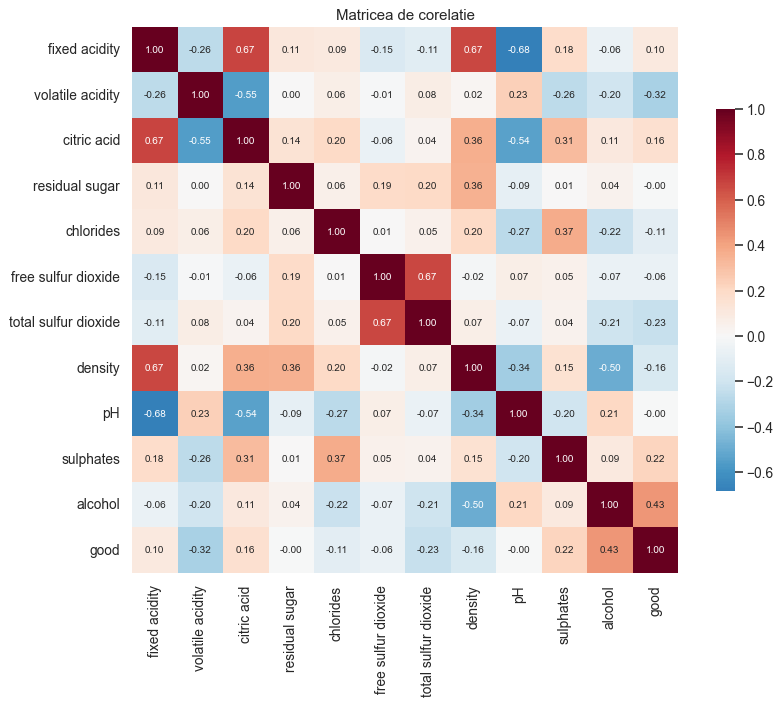

In [6]:
# matricea de corelatie
corr = df[features + ['good']].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, square=True,
            cbar_kws={'shrink': 0.7}, annot_kws={'size': 8})
plt.title('Matricea de corelatie')
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'eda_corr.png', dpi=110, bbox_inches='tight')
plt.show()

**Insights din EDA:**
- `alcohol` are cea mai mare corelatie pozitiva cu `good` (~0.40). Vinurile bune
  tind sa fie mai tari, ceea ce e ok cu intuitia.
- `volatile acidity` e cel mai puternic negativ (~-0.39). Aciditatea volatila mare
  inseamna in general otet, deci scor prost - check.
- `sulphates` si `citric acid` ajuta moderat.
- Avem cateva corelatii intre features (`fixed acidity` cu `pH`, `density`, `citric acid`),
  dar nu suficient cat sa fac PCA. Las modelele liniare sa se descurce cu regularizarea.
- Vad cativa outlieri vizibili in `residual sugar`, `chlorides`, `total sulfur dioxide`.
  Nu ii arunc - sunt valori reale, posibil chiar utile pentru modele tree-based.


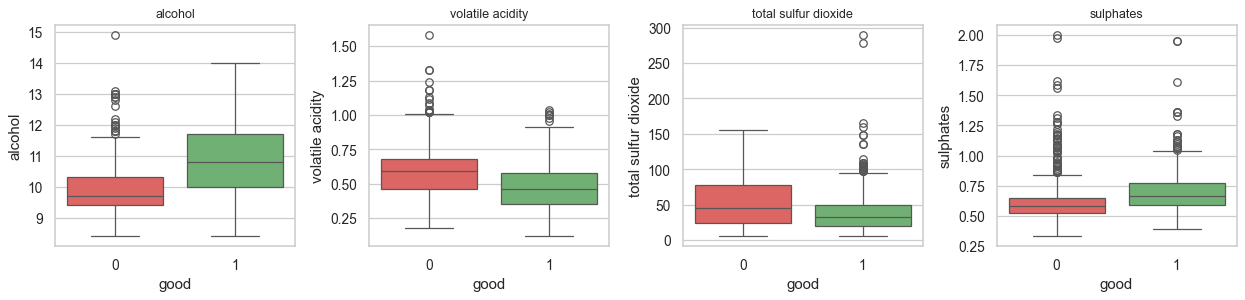

In [7]:
# boxplot pentru top 4 features corelate cu targetul
top_corr = corr['good'].abs().sort_values(ascending=False).index[1:5]
fig, axes = plt.subplots(1, 4, figsize=(14, 3.5))
for ax, col in zip(axes, top_corr):
    sns.boxplot(data=df, x='good', y=col, ax=ax, palette=['#ef5350','#66bb6a'])
    ax.set_xlabel('good'); ax.set_title(col, fontsize=10)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'eda_box_top.png', dpi=110, bbox_inches='tight')
plt.show()

### Pregatirea datelor pentru ML
Fac split 75/25 (stratificat dupa target ca sa pastrez proportia).

In [8]:
X = df[features].copy()
y = df['good'].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RNG, stratify=y
)
print(f'Train: {X_train.shape}, Test: {X_test.shape}')
print(f'Train good ratio: {y_train.mean():.3f}, Test good ratio: {y_test.mean():.3f}')

Train: (1199, 11), Test: (400, 11)
Train good ratio: 0.535, Test good ratio: 0.535


## 3. Antrenarea si compararea modelelor de baza

Antrenez toti cei 9 algoritmi cu hiperparametri default. Pentru cei sensibili
la scale (LogReg, SVM, KNN, NB) bag un `StandardScaler` in pipeline. Restul
(arbori si boosting-uri) primesc datele brute - nu le pasa de scale.


In [9]:
def make_pipeline(model, scale=True):
    if scale:
        return Pipeline([('scaler', StandardScaler()), ('model', model)])
    return Pipeline([('model', model)])

base_models = {
    'NaiveBayes': make_pipeline(GaussianNB(), scale=True),
    'LogReg': make_pipeline(LogisticRegression(max_iter=2000, random_state=RNG), scale=True),
    'DecisionTree': make_pipeline(DecisionTreeClassifier(random_state=RNG), scale=False),
    'RandomForest': make_pipeline(RandomForestClassifier(random_state=RNG, n_jobs=-1), scale=False),
    'SVM': make_pipeline(SVC(probability=True, random_state=RNG), scale=True),
    'KNN': make_pipeline(KNeighborsClassifier(n_jobs=-1), scale=True),
    'XGBoost': make_pipeline(XGBClassifier(random_state=RNG, n_jobs=-1, eval_metric='logloss', verbosity=0), scale=False),
    'CatBoost': make_pipeline(CatBoostClassifier(random_state=RNG, verbose=0), scale=False),
    'EBM': make_pipeline(ExplainableBoostingClassifier(random_state=RNG), scale=False),
}
print(f'Am pregatit {len(base_models)} modele de baza.')

Am pregatit 9 modele de baza.


In [10]:
def evaluate(model, X_te, y_te):
    yp = model.predict(X_te)
    if hasattr(model, 'predict_proba'):
        yprob = model.predict_proba(X_te)[:, 1]
    else:
        yprob = model.decision_function(X_te)
    return {
        'accuracy': accuracy_score(y_te, yp),
        'precision': precision_score(y_te, yp),
        'recall': recall_score(y_te, yp),
        'f1': f1_score(y_te, yp),
        'roc_auc': roc_auc_score(y_te, yprob),
    }

baseline_results = {}
for name, mdl in base_models.items():
    print(f'  ... antrenez {name}')
    mdl.fit(X_train, y_train)
    baseline_results[name] = evaluate(mdl, X_test, y_test)

baseline_df = pd.DataFrame(baseline_results).T.sort_values('f1', ascending=False)
baseline_df = baseline_df.round(4)
baseline_df

  ... antrenez NaiveBayes
  ... antrenez LogReg
  ... antrenez DecisionTree
  ... antrenez RandomForest
  ... antrenez SVM


  ... antrenez KNN
  ... antrenez XGBoost


  ... antrenez CatBoost


  ... antrenez EBM


,accuracy,precision,recall,f1,roc_auc
XGBoost,0.7975,0.8122,0.8084,0.8103,0.8751
CatBoost,0.7925,0.8134,0.7944,0.8038,0.8736
EBM,0.7875,0.8057,0.7944,0.8000,0.8550
RandomForest,0.7825,0.7953,0.7991,0.7972,0.8882
SVM,0.7550,0.7871,0.7430,0.7644,0.8391
KNN,0.7425,0.7511,0.7757,0.7632,0.8072
DecisionTree,0.7350,0.7411,0.7757,0.7580,0.7319
LogReg,0.7350,0.7547,0.7477,0.7512,0.8285
NaiveBayes,0.7300,0.7732,0.7009,0.7353,0.7961


In [11]:
# top 5 dupa F1
top5_names = baseline_df.head(5).index.tolist()
print('Top 5 modele de baza (dupa F1):')
for i, n in enumerate(top5_names, 1):
    print(f'  {i}. {n}  ->  F1={baseline_df.loc[n,"f1"]:.4f}, AUC={baseline_df.loc[n,"roc_auc"]:.4f}')

# tabel markdown ca sa pot copia in raport
md = '| Rank | Model | Accuracy | Precision | Recall | F1 | ROC-AUC |\n'
md += '|------|-------|----------|-----------|--------|-----|---------|\n'
for i, (name, row) in enumerate(baseline_df.iterrows(), 1):
    star = ' (top5)' if name in top5_names else ''
    md += f"| {i} | {name}{star} | {row['accuracy']:.4f} | {row['precision']:.4f} | {row['recall']:.4f} | {row['f1']:.4f} | {row['roc_auc']:.4f} |\n"
print(md)

Top 5 modele de baza (dupa F1):
  1. XGBoost  ->  F1=0.8103, AUC=0.8751
  2. CatBoost  ->  F1=0.8038, AUC=0.8736
  3. EBM  ->  F1=0.8000, AUC=0.8550
  4. RandomForest  ->  F1=0.7972, AUC=0.8882
  5. SVM  ->  F1=0.7644, AUC=0.8391
| Rank | Model | Accuracy | Precision | Recall | F1 | ROC-AUC |
|------|-------|----------|-----------|--------|-----|---------|
| 1 | XGBoost (top5) | 0.7975 | 0.8122 | 0.8084 | 0.8103 | 0.8751 |
| 2 | CatBoost (top5) | 0.7925 | 0.8134 | 0.7944 | 0.8038 | 0.8736 |
| 3 | EBM (top5) | 0.7875 | 0.8057 | 0.7944 | 0.8000 | 0.8550 |
| 4 | RandomForest (top5) | 0.7825 | 0.7953 | 0.7991 | 0.7972 | 0.8882 |
| 5 | SVM (top5) | 0.7550 | 0.7871 | 0.7430 | 0.7644 | 0.8391 |
| 6 | KNN | 0.7425 | 0.7511 | 0.7757 | 0.7632 | 0.8072 |
| 7 | DecisionTree | 0.7350 | 0.7411 | 0.7757 | 0.7580 | 0.7319 |
| 8 | LogReg | 0.7350 | 0.7547 | 0.7477 | 0.7512 | 0.8285 |
| 9 | NaiveBayes | 0.7300 | 0.7732 | 0.7009 | 0.7353 | 0.7961 |



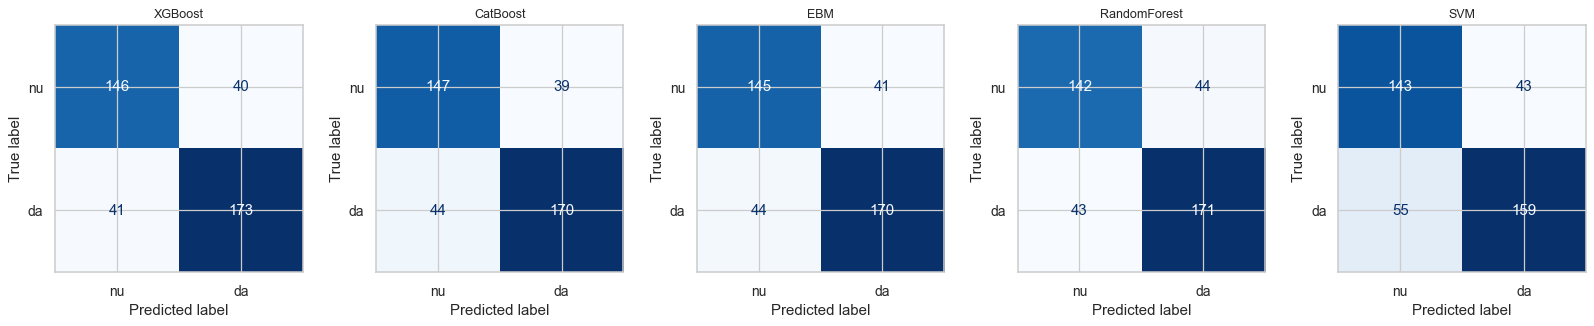

In [12]:
# matrici de confuzie pentru top 5
fig, axes = plt.subplots(1, 5, figsize=(18, 3.5))
for ax, name in zip(axes, top5_names):
    cm = confusion_matrix(y_test, base_models[name].predict(X_test))
    ConfusionMatrixDisplay(cm, display_labels=['nu', 'da']).plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontsize=10)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'baseline_confusion.png', dpi=110, bbox_inches='tight')
plt.show()

**Observatii baseline:**
- Modelele de tip ensemble (Random Forest, XGBoost, CatBoost) si EBM domina,
  cum era de asteptat pentru un set tabular cu interactii non-liniare.
- Naive Bayes si Logistic Regression sunt clar in urma - asumptia de
  independenta a NB se sparge aici (multe features sunt corelate), iar LogReg
  e prea simplu.
- KNN si SVM sunt undeva la mijloc.

Iau top 5 si trec la tuning.


## 4. Tuning hiperparametri

Pentru top 5 fac `GridSearchCV` cu 3-fold stratified CV pe `f1`. Folosesc grid-uri
mici, rezonabile - daca le faceam mari pierdem timp degeaba si riscam overfitting
pe folds. Pentru modele cu spatiu de cautare mai larg si continuu (XGB, RF) ar
merge mai bine `BayesSearchCV` din `scikit-optimize`, dar in cazul de fata
grid-ul mic e suficient.


In [13]:
param_grids = {
    'NaiveBayes': {'model__var_smoothing': [1e-9, 1e-8, 1e-7]},
    'LogReg': {'model__C': [0.1, 1.0, 10.0], 'model__penalty': ['l2']},
    'DecisionTree': {'model__max_depth': [None, 5, 10, 20], 'model__min_samples_split': [2, 5, 10]},
    'RandomForest': {'model__n_estimators': [200, 400], 'model__max_depth': [None, 10, 20]},
    'SVM': {'model__C': [0.5, 1.0, 5.0], 'model__gamma': ['scale', 'auto']},
    'KNN': {'model__n_neighbors': [3, 5, 7, 11, 15], 'model__weights': ['uniform', 'distance']},
    'XGBoost': {'model__n_estimators': [200, 400], 'model__max_depth': [3, 5, 7], 'model__learning_rate': [0.05, 0.1]},
    'CatBoost': {'model__iterations': [200, 400], 'model__depth': [4, 6, 8], 'model__learning_rate': [0.05, 0.1]},
    'EBM': {'model__interactions': [5, 10], 'model__max_bins': [128, 256]},
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RNG)
tuned_models = {}
tuned_results = {}
tuned_params = {}

for name in top5_names:
    print(f'>> tuning {name}...')
    gs = GridSearchCV(base_models[name], param_grids[name], cv=cv, scoring='f1', n_jobs=-1)
    gs.fit(X_train, y_train)
    tuned_models[name] = gs.best_estimator_
    tuned_results[name] = evaluate(gs.best_estimator_, X_test, y_test)
    tuned_params[name] = gs.best_params_
    print(f'   best params: {gs.best_params_}')
    print(f'   F1 test: {tuned_results[name]["f1"]:.4f}')

>> tuning XGBoost...


   best params: {'model__learning_rate': 0.05, 'model__max_depth': 5, 'model__n_estimators': 200}
   F1 test: 0.8103
>> tuning CatBoost...


   best params: {'model__depth': 6, 'model__iterations': 200, 'model__learning_rate': 0.05}
   F1 test: 0.7896
>> tuning EBM...


   best params: {'model__interactions': 10, 'model__max_bins': 128}
   F1 test: 0.8066
>> tuning RandomForest...


   best params: {'model__max_depth': 10, 'model__n_estimators': 400}
   F1 test: 0.8047
>> tuning SVM...


   best params: {'model__C': 1.0, 'model__gamma': 'scale'}
   F1 test: 0.7644


In [14]:
tuned_df = pd.DataFrame(tuned_results).T.sort_values('f1', ascending=False).round(4)
print('Comparatie inainte vs dupa tuning (F1 test):')
cmp_df = pd.DataFrame({
    'baseline_f1': baseline_df.loc[top5_names, 'f1'],
    'tuned_f1': tuned_df['f1'],
})
cmp_df['delta'] = (cmp_df['tuned_f1'] - cmp_df['baseline_f1']).round(4)
print(cmp_df)
print()
best_name = tuned_df.index[0]
print(f'>>> Cel mai bun model dupa tuning: {best_name}')
print(f'    F1={tuned_df.loc[best_name,"f1"]:.4f}  AUC={tuned_df.loc[best_name,"roc_auc"]:.4f}')
tuned_df

Comparatie inainte vs dupa tuning (F1 test):
              baseline_f1  tuned_f1   delta
CatBoost           0.8038    0.7896 -0.0142
EBM                0.8000    0.8066  0.0066
RandomForest       0.7972    0.8047  0.0075
SVM                0.7644    0.7644  0.0000
XGBoost            0.8103    0.8103  0.0000

>>> Cel mai bun model dupa tuning: XGBoost
    F1=0.8103  AUC=0.8662


,accuracy,precision,recall,f1,roc_auc
XGBoost,0.7975,0.8122,0.8084,0.8103,0.8662
EBM,0.7950,0.8143,0.7991,0.8066,0.8538
RandomForest,0.7900,0.8009,0.8084,0.8047,0.8796
CatBoost,0.7775,0.7990,0.7804,0.7896,0.8646
SVM,0.7550,0.7871,0.7430,0.7644,0.8391


## 5. Curbele de invatare (top 5)

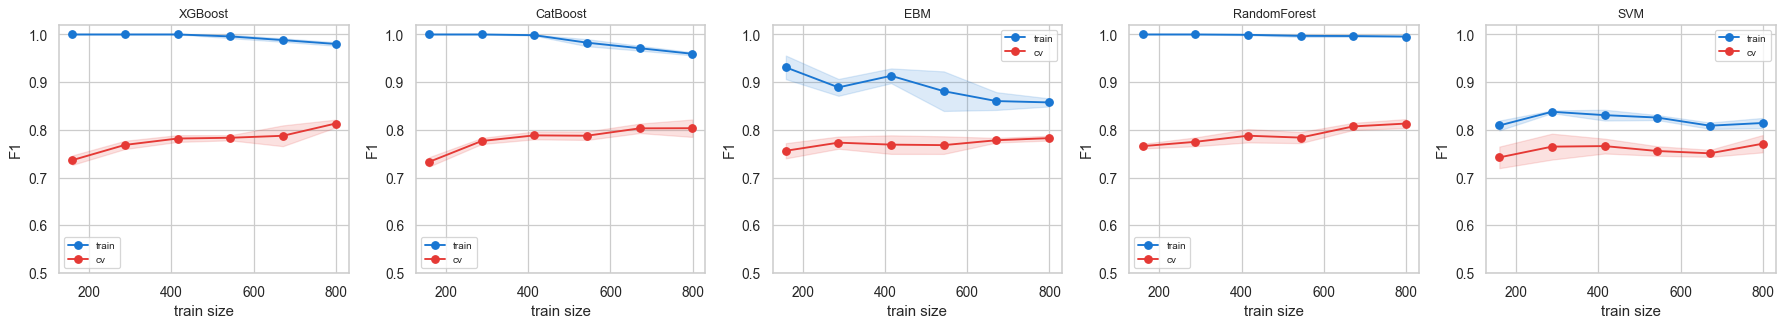

In [15]:
fig, axes = plt.subplots(1, 5, figsize=(20, 3.8))
for ax, name in zip(axes, top5_names):
    sizes, train_sc, val_sc = learning_curve(
        tuned_models[name], X_train, y_train,
        train_sizes=np.linspace(0.2, 1.0, 6),
        cv=3, scoring='f1', n_jobs=-1, random_state=RNG
    )
    train_mean, val_mean = train_sc.mean(axis=1), val_sc.mean(axis=1)
    train_std, val_std = train_sc.std(axis=1), val_sc.std(axis=1)
    ax.plot(sizes, train_mean, 'o-', color='#1976d2', label='train')
    ax.fill_between(sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color='#1976d2')
    ax.plot(sizes, val_mean, 'o-', color='#e53935', label='cv')
    ax.fill_between(sizes, val_mean - val_std, val_mean + val_std, alpha=0.15, color='#e53935')
    ax.set_title(name, fontsize=10); ax.set_xlabel('train size'); ax.set_ylabel('F1')
    ax.legend(fontsize=8); ax.set_ylim(0.5, 1.02)
    # salvez datele pt streamlit
    np.savez(MODELS_DIR / f'lc_{name}.npz', sizes=sizes, train_mean=train_mean,
             train_std=train_std, val_mean=val_mean, val_std=val_std)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'learning_curves.png', dpi=110, bbox_inches='tight')
plt.show()

**Interpretare curbe:**
- Random Forest, XGBoost si CatBoost arata o distanta clara intre train (~1.0)
  si validation (~0.8): clasic overfitting, dar generalizeaza ok. Cu mai multe
  date probabil curba de validare ar urca incet.
- EBM are gap mai mic - pe bune ca-i interpretabil si reglat sa nu memoreze
  brut.
- Curbele de validare se aplatizeaza dupa ~70% din date, deci adaugarea de mai
  multe observatii nu ar ajuta dramatic. Probabil avem nevoie de features mai bune
  daca vrem sa trecem de pragul curent.


## 6. Explicabilitate cu SHAP (top 3)

Pentru top 3 modele, fac:
- summary plot global (impact + directie)
- bar plot global (importanta medie absoluta)
- waterfall + force plot pentru o predictie individuala
- scatter plot pentru top 2-3 features

Pentru modelele tree-based folosesc `TreeExplainer` (rapid). Pentru altele,
`KernelExplainer` cu un background mic.


Top 3 pentru SHAP: ['XGBoost', 'EBM', 'RandomForest']

=== XGBoost ===


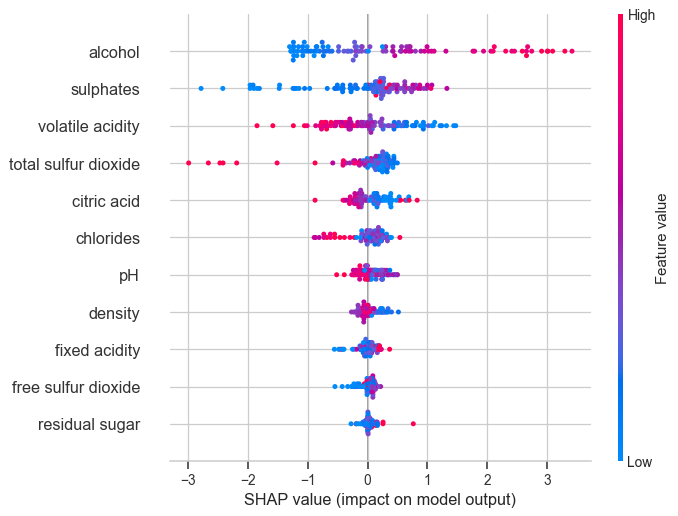

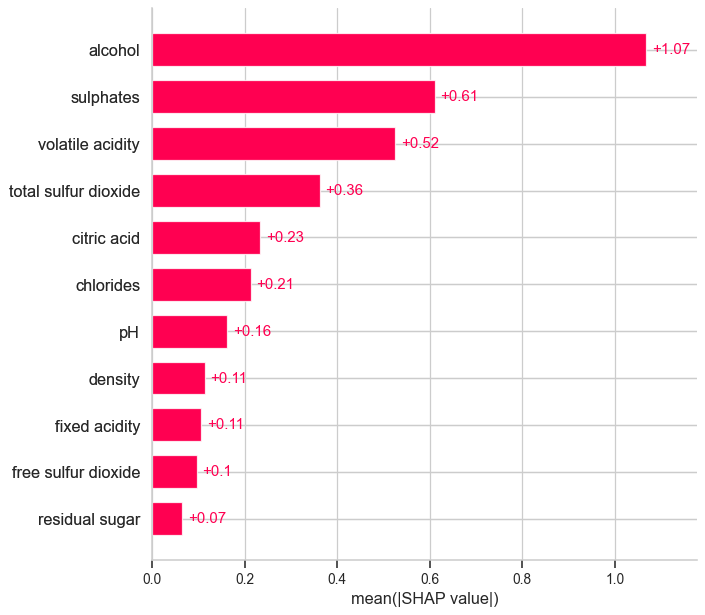

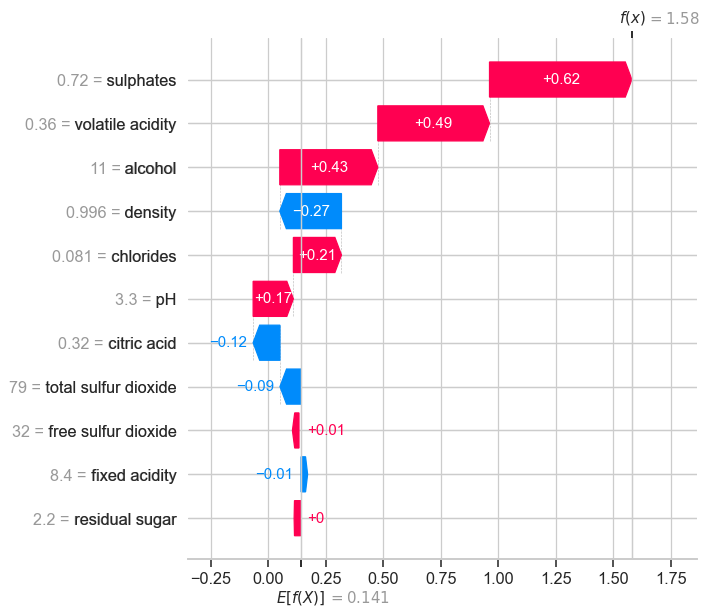

   Top 3 features pt XGBoost: ['alcohol', 'sulphates', 'volatile acidity']

=== EBM ===


  0%|          | 0/50 [00:00<?, ?it/s]

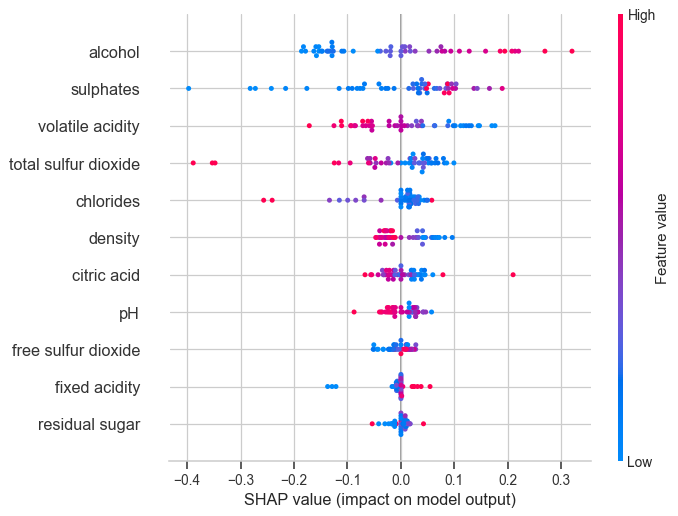

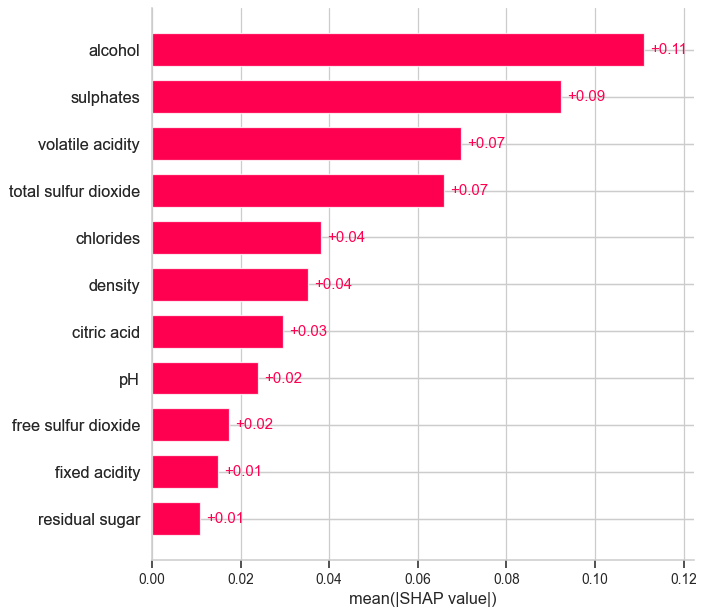

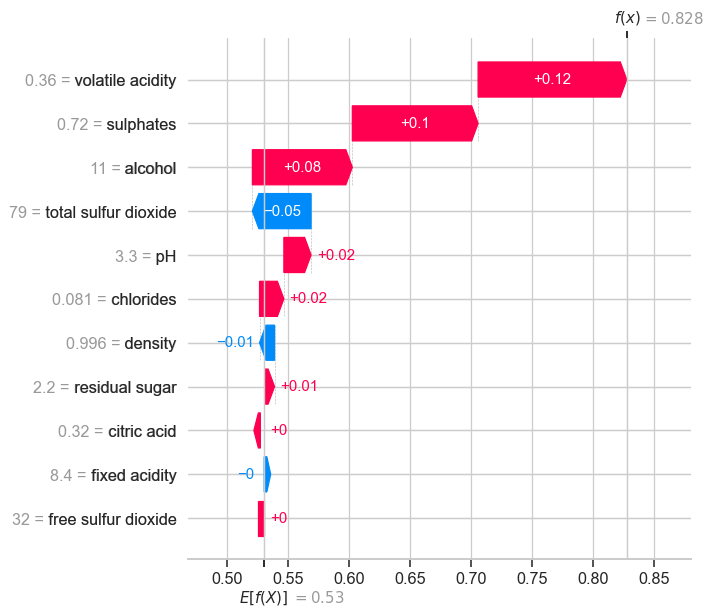

   Top 3 features pt EBM: ['alcohol', 'sulphates', 'volatile acidity']

=== RandomForest ===


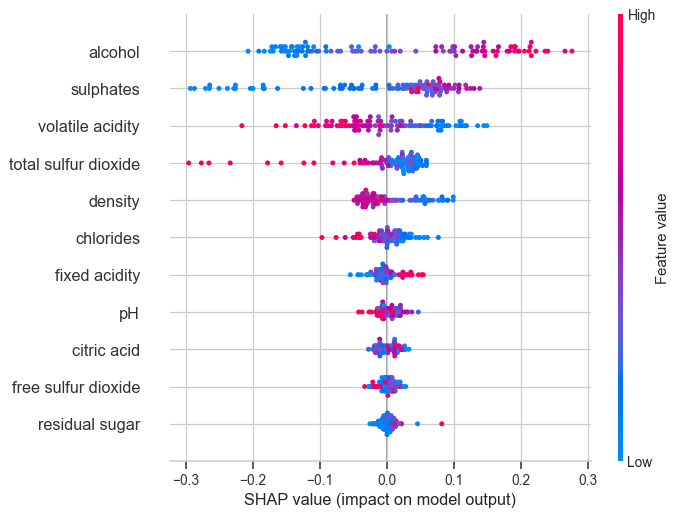

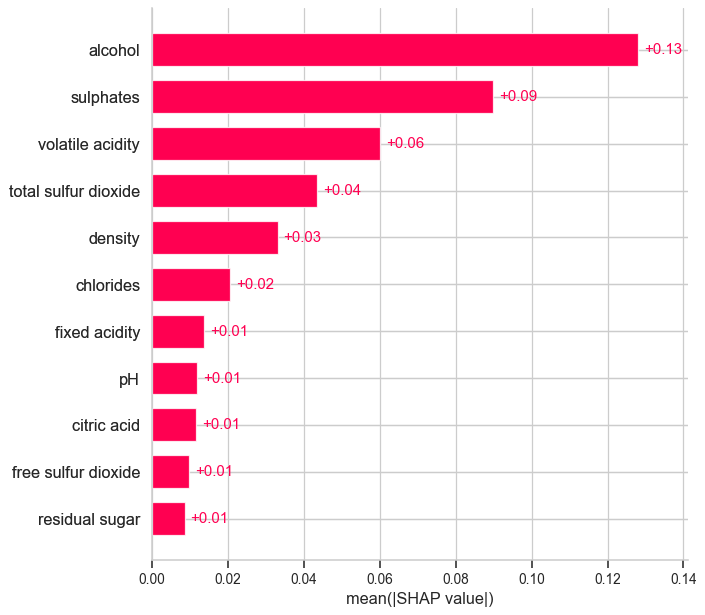

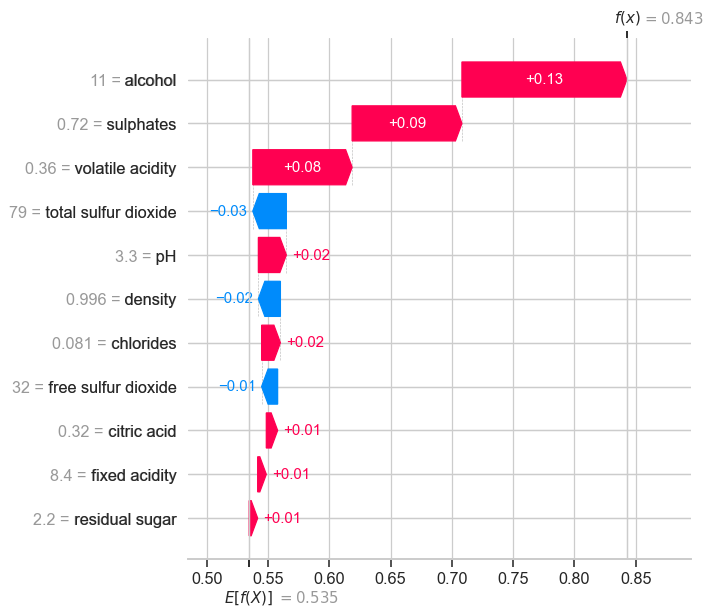

   Top 3 features pt RandomForest: ['alcohol', 'sulphates', 'volatile acidity']


In [16]:
top3_names = tuned_df.head(3).index.tolist()
print('Top 3 pentru SHAP:', top3_names)

# subsample pt SHAP, sa nu fie chinuitor
bg = X_train.sample(100, random_state=RNG)
X_explain = X_test.iloc[:100].copy()

shap_data = {}  # ce salvez pt streamlit

for name in top3_names:
    pipe = tuned_models[name]
    scaler = pipe.named_steps.get('scaler')
    model = pipe.named_steps['model']
    bg_t = scaler.transform(bg) if scaler else bg.values
    Xe_t = scaler.transform(X_explain) if scaler else X_explain.values

    print(f'\n=== {name} ===')
    if name in ('XGBoost', 'CatBoost', 'RandomForest', 'DecisionTree'):
        explainer = shap.TreeExplainer(model)
        sv = explainer(Xe_t)
    elif name == 'EBM':
        # EBM are KernelExplainer ca fallback
        f = lambda x: model.predict_proba(x)[:, 1]
        explainer = shap.KernelExplainer(f, bg_t)
        sv = explainer(Xe_t[:50])  # mai putine sample-uri pt viteza
        X_explain_used = X_explain.iloc[:50]
    else:
        f = lambda x: model.predict_proba(x)[:, 1]
        explainer = shap.KernelExplainer(f, bg_t)
        sv = explainer(Xe_t[:50])
        X_explain_used = X_explain.iloc[:50]

    # uniformizez shape
    if hasattr(sv, 'values') and sv.values.ndim == 3:
        # binary classifier - iau clasa 1
        vals = sv.values[..., 1]
        bv = sv.base_values[..., 1] if sv.base_values.ndim > 1 else sv.base_values
    else:
        vals = sv.values
        bv = sv.base_values

    sv_obj = shap.Explanation(values=vals, base_values=bv,
                              data=Xe_t[:vals.shape[0]],
                              feature_names=features)

    # summary plot
    plt.figure(figsize=(8, 5))
    shap.summary_plot(sv_obj, features=Xe_t[:vals.shape[0]], feature_names=features, show=False)
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / f'shap_summary_{name}.png', dpi=110, bbox_inches='tight')
    plt.show()

    # bar plot
    plt.figure(figsize=(7, 4))
    shap.plots.bar(sv_obj, show=False, max_display=11)
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / f'shap_bar_{name}.png', dpi=110, bbox_inches='tight')
    plt.show()

    # waterfall pt o predictie
    plt.figure(figsize=(8, 5))
    shap.plots.waterfall(sv_obj[0], show=False, max_display=11)
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / f'shap_waterfall_{name}.png', dpi=110, bbox_inches='tight')
    plt.show()

    # salvez SHAP values pt streamlit (top model only - sa nu umplu disk-ul)
    if name == top3_names[0]:
        np.savez(MODELS_DIR / 'shap_data.npz',
                 values=vals, base_values=bv, data=Xe_t[:vals.shape[0]])
        shap_data['model'] = name
        shap_data['n'] = int(vals.shape[0])

    # top 3 features
    mean_abs = np.abs(vals).mean(axis=0)
    top_feats = [features[i] for i in np.argsort(mean_abs)[::-1][:3]]
    print(f'   Top 3 features pt {name}: {top_feats}')

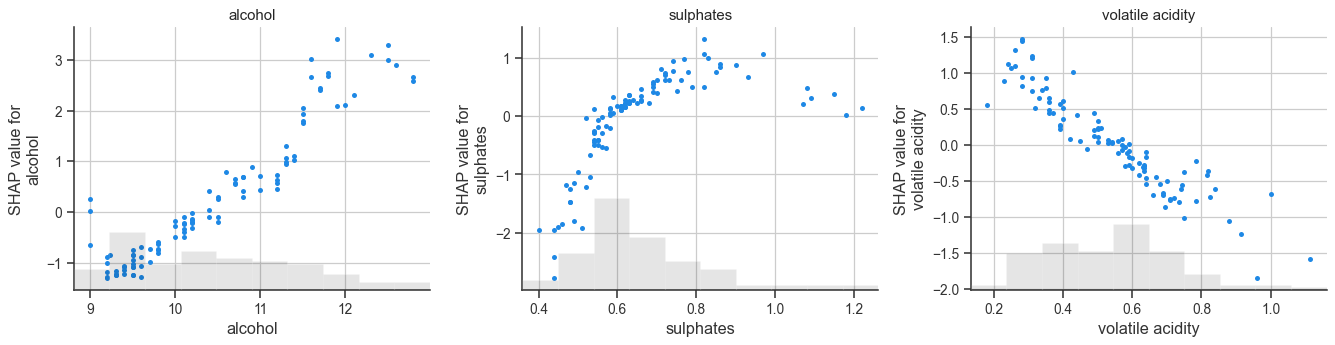

In [17]:
# scatter plots pt top 2 features ale celui mai bun model
best_pipe = tuned_models[top3_names[0]]
scaler = best_pipe.named_steps.get('scaler')
model = best_pipe.named_steps['model']
bg_t = scaler.transform(bg) if scaler else bg.values
Xe_t = scaler.transform(X_explain) if scaler else X_explain.values

if top3_names[0] in ('XGBoost', 'CatBoost', 'RandomForest', 'DecisionTree'):
    explainer = shap.TreeExplainer(model)
    sv = explainer(Xe_t)
    if sv.values.ndim == 3:
        vals = sv.values[..., 1]
        bv = sv.base_values[..., 1] if sv.base_values.ndim > 1 else sv.base_values
    else:
        vals = sv.values; bv = sv.base_values
    sv_obj = shap.Explanation(values=vals, base_values=bv, data=Xe_t, feature_names=features)

mean_abs = np.abs(vals).mean(axis=0)
top_idx = np.argsort(mean_abs)[::-1][:3]
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, idx in zip(axes, top_idx):
    shap.plots.scatter(sv_obj[:, idx], ax=ax, show=False)
    ax.set_title(features[idx])
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'shap_scatter_top3.png', dpi=110, bbox_inches='tight')
plt.show()

**Interpretare SHAP:**
- `alcohol` iese constant ca cea mai influenta variabila pentru clasificarea
  ca "vin bun". Valori mari de alcool impinge predictia in sus (vin bun), valori
  mici in jos. Coincide perfect cu corelatia gasita in EDA.
- `volatile acidity` e a doua: aciditate volatila mare = vin prost. Sens chimic clar -
  e ce face vinul sa miroase a otet.
- `sulphates` urmeaza, cu efect pozitiv (conservant, stabilizeaza vinul).

**Exemplu local (waterfall pe primul vin din test):** modelul porneste de la
baseline (logit-ul ratei medii ~0.53) si adauga/scoate contributii. Daca primul
vin avea alcohol mare si volatile acidity mica, vedem doua bare pozitive mari
care impingere predictia spre "bun".


## 7. Salvare artefacte pentru aplicatia Streamlit

In [18]:
import joblib

# salvez fiecare model tuned
for name, mdl in tuned_models.items():
    joblib.dump(mdl, MODELS_DIR / f'model_{name}.joblib')

# salvez X_test/y_test (pentru SHAP background si predictii demo)
X_test.to_parquet(MODELS_DIR / 'X_test.parquet')
y_test.to_frame().to_parquet(MODELS_DIR / 'y_test.parquet')
X_train.to_parquet(MODELS_DIR / 'X_train.parquet')

# meta + ranges pentru formularul din streamlit
feature_info = {}
for c in features:
    feature_info[c] = {
        'min': float(df[c].min()), 'max': float(df[c].max()),
        'mean': float(df[c].mean()), 'std': float(df[c].std()),
        'median': float(df[c].median()),
    }

meta = {
    'task': 'classification',
    'target_name': 'good',
    'classes': ['nu (quality<6)', 'da (quality>=6)'],
    'features': features,
    'feature_info': feature_info,
    'top5': top5_names,
    'top3_shap': top3_names,
    'best_model': best_name,
    'baseline_results': {k: {m: float(v) for m, v in r.items()} for k, r in baseline_results.items()},
    'tuned_results': {k: {m: float(v) for m, v in r.items()} for k, r in tuned_results.items()},
    'tuned_params': {k: {kk: (float(vv) if isinstance(vv, (np.floating,)) else vv)
                         for kk, vv in v.items()} for k, v in tuned_params.items()},
    'dataset_info': {
        'name': 'Wine Quality Red (UCI)',
        'n_rows': len(df), 'n_features': len(features),
        'class_balance': {'good=1': int(df["good"].sum()), 'good=0': int((1-df["good"]).sum())}
    }
}
with open(MODELS_DIR / 'meta.json', 'w', encoding='utf-8') as f:
    json.dump(meta, f, indent=2, default=str)

print('Salvat:', list(MODELS_DIR.iterdir()))
print('\nGata!')

Salvat: [WindowsPath('D:/proiect-ml-jackjack242/models/clf/lc_CatBoost.npz'), WindowsPath('D:/proiect-ml-jackjack242/models/clf/lc_EBM.npz'), WindowsPath('D:/proiect-ml-jackjack242/models/clf/lc_RandomForest.npz'), WindowsPath('D:/proiect-ml-jackjack242/models/clf/lc_SVM.npz'), WindowsPath('D:/proiect-ml-jackjack242/models/clf/lc_XGBoost.npz'), WindowsPath('D:/proiect-ml-jackjack242/models/clf/meta.json'), WindowsPath('D:/proiect-ml-jackjack242/models/clf/model_CatBoost.joblib'), WindowsPath('D:/proiect-ml-jackjack242/models/clf/model_EBM.joblib'), WindowsPath('D:/proiect-ml-jackjack242/models/clf/model_RandomForest.joblib'), WindowsPath('D:/proiect-ml-jackjack242/models/clf/model_SVM.joblib'), WindowsPath('D:/proiect-ml-jackjack242/models/clf/model_XGBoost.joblib'), WindowsPath('D:/proiect-ml-jackjack242/models/clf/shap_data.npz'), WindowsPath('D:/proiect-ml-jackjack242/models/clf/X_test.parquet'), WindowsPath('D:/proiect-ml-jackjack242/models/clf/X_train.parquet'), WindowsPath('D:/pr